# A Gentle Introduction to Physics-Informed Neural Networks, with Applications in Static Rod and Beam Problems

### Authors     : Dimitrios Katsikis, Aliki D. Muradova and Georgios E. Stavroulakis

Code reproduced : Khin Thandar Kyaw 

Date            : 16 Sep 2026

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
# Rod parameters
L = 1.0 # rod length
A = 1.0 # cross-sectional area
E = 1.0 # Young's modulus
c = 1.0 # distributed load constant

In [3]:
def exact_solution(x):
    return (3*x - x**3) / 6

In [ ]:
# Number of collocation points
N_f = 1000

# Random points inside the rod: 0 <= x <= 1
x_f = np.random.rand(N_f, 1)

# Convert Numpy array to Tensorflow tensor
x_f = tf.convert_to_tensor(x_f, dtype = tf.float32)

In [6]:
# Boundary points
x_left = tf.constant([[0.0]], dtype = tf.float32)
x_right = tf.constant([[1.0]], dtype = tf.float32)

$ x \rightarrow NN \rightarrow \hat{u}(x)$

In [13]:
# Neural Network
def build_model():
    model = tf.keras.Sequential([tf.keras.layers.Input(shape=(1,)),
                                tf.keras.layers.Dense(20, 
                                                        activation='tanh', 
                                                        kernel_initializer='he_normal'),
                                tf.keras.layers.Dense(30, 
                                                        activation='tanh',
                                                        kernel_initializer='he_normal'),
                                tf.keras.layers.Dense(60, 
                                                        activation='tanh',
                                                        kernel_initializer='he_normal'),
                                tf.keras.layers.Dense(40, 
                                                        activation='tanh',
                                                        kernel_initializer='he_normal'),
                                tf.keras.layers.Dense(20,
                                                        activation='tanh',
                                                        kernel_initializer='he_normal'),
                                tf.keras.layers.Dense(1, activation=None)
                                ])
    return model

In [14]:
model = build_model()

$$
x \rightarrow NN \rightarrow \hat{u}(x)
\rightarrow
\frac{d\hat{u}}{dx}
\rightarrow
\frac{d^2\hat{u}}{dx^2}
$$

In [18]:
# Automatic Differentiation
def get_derivatives(model, x):
    # Outer tape: used for second derivative
    with tf.GradientTape() as tape2:
        tape2.watch(x) # force the tape to track x

        # Inner tape: used for first derivative 
        with tf.GradientTape() as tape1:
            tape1.watch(x) # force the tape to track x

            # Neural network prediction
            u_hat = model(x)

        # First derivative: du_hat/dx
        du_dx = tape1.gradient(u_hat, x)

    # Second dertivative : d^2u_hat/dx^2
    d2u_dx2 = tape2.gradient(du_dx, x)

    return u_hat, du_dx, d2u_dx2


In [19]:
u_hat, du_dx, d2u_dx2 = get_derivatives(model, x_f)

In [20]:
print(f"u_hat shape : {u_hat.shape}")
print(f"du_dx shape : {du_dx.shape}")
print(f"d2u_dx2 shape : {d2u_dx2.shape}")

u_hat shape : (1000, 1)
du_dx shape : (1000, 1)
d2u_dx2 shape : (1000, 1)


## PINN Loss

Physics equation:
$$AE\frac{d^2u}{dx^2}+cx=0$$


PINN approximation:


$$u(x) \approx \hat{u}(x)$$


Physics residual:


$$r(x)=AE\frac{d^2\hat{u}}{dx^2}+cx$$


Physics loss:

$$
L_{\text{physics}}
=
\frac{1}{N_f}
\sum_{i=1}^{N_f}
r(x_i)^2
$$

Boundary conditions:

$$
\hat{u}(0)=0

\frac{d\hat{u}}{dx}(1)=0
$$

Total loss:

$$
L
=
L_{\text{physics}}
+
L_{\text{left}}
+
L_{\text{right}}
$$

In [27]:
# PINN Loss
def compute_loss(model, x_f, x_left, x_right):
    # physics equation inside the rod
    _, _, u_xx_physics = get_derivatives(model, x_f)

    # physics residual
    # A*E*&u'' + c*x = 0
    physics_residual = A * E * u_xx_physics + c * x_f

    physics_loss = tf.reduce_mean(tf.square(physics_residual))

    # left boundary : u(0) = 0
    u_left = model(x_left)

    left_boundary_loss = tf.reduce_mean(tf.square(u_left))

    # right boundary : u'(1) = 0
    _, u_x_right, _ = get_derivatives(model, x_right)

    right_boundary_loss = tf.reduce_mean(tf.square(u_x_right))

    # Total PINN loss
    total_loss = physics_loss + left_boundary_loss + right_boundary_loss

    return total_loss, physics_loss, left_boundary_loss, right_boundary_loss

In [28]:
total_loss, physics_loss, left_loss, right_loss = compute_loss(model, x_f, x_left, x_right)

print(f"Total loss: {total_loss.numpy()}")
print(f"Physics loss: {physics_loss.numpy()}")
print(f"Left BC loss: {left_loss.numpy()}")
print(f"Right BC loss: {right_loss.numpy()}")

Total loss: 85.02701568603516
Physics loss: 84.98835754394531
Left BC loss: 0.0
Right BC loss: 0.03865833953022957


In [29]:
optimizer = tf.keras.optimizers.Adam()

In [33]:
def train_step(model, x_physics, x_left, x_right):
    # Record how total loss depends on
    # the NN weights and biases
    with tf.GradientTape() as tape:
        total_loss, physics_loss, left_loss, right_loss = compute_loss(model, x_physics, x_left, x_right)

        # dLoss / d(weights, biases)
        # dLoss / dweights, dLoss / dbiases
        gradients = tape.gradient(total_loss, model.trainable_variables)

    # Update weights and biases
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    return total_loss, physics_loss, left_loss, right_loss

### 2 Types of derivative
x derivative $\rightarrow$ physics

W, b derivative $\rightarrow$ training

In [ ]:
epochs = 5000

for epoch in range(epochs):
    total_loss, physics_loss, left_loss, right_loss = train_step(model, x_f, x_left, x_right)

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"Total: {total_loss.numpy():.6e} | "
            f"Physics: {physics_loss.numpy():.6e} | "
            f"Left: {left_loss.numpy():.6e} | "
            f"Right: {right_loss.numpy():.6e}"
        )

Epoch    0 | Total: 5.896634e+01 | Physics: 5.893858e+01 | Left: 6.100764e-04 | Right: 2.715268e-02
Epoch  100 | Total: 9.516018e-02 | Physics: 6.520814e-02 | Left: 3.111339e-06 | Right: 2.994893e-02
Epoch  200 | Total: 5.453504e-02 | Physics: 3.361323e-02 | Left: 3.784446e-06 | Right: 2.091803e-02
Epoch  300 | Total: 3.932308e-02 | Physics: 2.908950e-02 | Left: 1.328558e-06 | Right: 1.023224e-02
Epoch  400 | Total: 3.063123e-02 | Physics: 2.572842e-02 | Left: 4.666701e-07 | Right: 4.902335e-03
Epoch  500 | Total: 2.426995e-02 | Physics: 2.171657e-02 | Left: 1.942674e-07 | Right: 2.553181e-03
Epoch  600 | Total: 1.928562e-02 | Physics: 1.786103e-02 | Left: 8.679117e-08 | Right: 1.424502e-03
Epoch  700 | Total: 1.544511e-02 | Physics: 1.462315e-02 | Left: 3.276866e-08 | Right: 8.219300e-04
Epoch  800 | Total: 1.255199e-02 | Physics: 1.207026e-02 | Left: 6.893241e-09 | Right: 4.817254e-04
Epoch  900 | Total: 1.038689e-02 | Physics: 1.010002e-02 | Left: 1.788583e-12 | Right: 2.868662e-04


In [36]:
# Compare PINN with exact solution
x_test = np.linspace(0.0, 1.0, 200).reshape(-1, 1)

x_test_tf = tf.convert_to_tensor(x_test, dtype = tf.float32)

$$x_{\text{test}} \rightarrow \text{NN} \rightarrow \hat{u}_{(x_{\text{test}})}$$

In [37]:
u_pinn = model(x_test_tf)

In [38]:
u_exact = exact_solution(x_test)

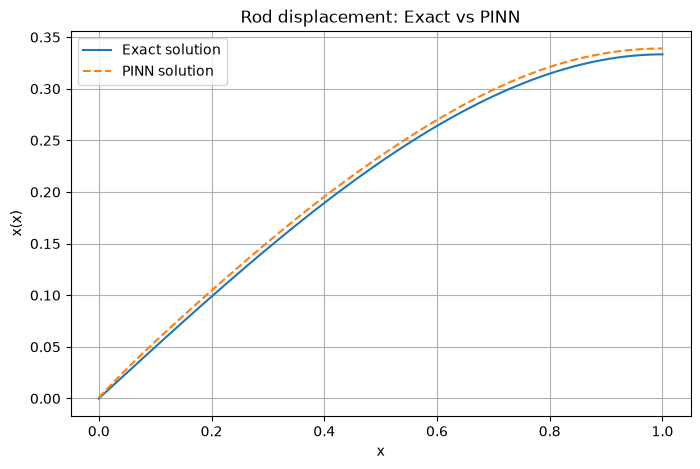

In [39]:
plt.figure(figsize = (8, 5))

plt.plot(x_test, u_exact, label = "Exact solution")

plt.plot(x_test, u_pinn, "--", label = "PINN solution")

plt.xlabel("x")
plt.ylabel("x(x)")
plt.title("Rod displacement: Exact vs PINN")

plt.legend()
plt.grid()

plt.show()

In [40]:
mse = np.mean((u_exact - u_pinn)**2)

print(f"Solution MSE: {mse}")

Solution MSE: 3.340888724778779e-05


In [42]:
# check if the boundary conditions are satisfied
u_left_pred = model(x_left)
print(f"u(0) = {u_left_pred.numpy()[0, 0]}")

_, u_x_right, _ = get_derivatives(model, x_right)
print(f"u_x(1) = {u_x_right.numpy()[0, 0]}")

u(0) = 0.0007374025881290436
u_x(1) = 0.0025390926748514175


In [43]:
# check if the physics equation is solved
_, _, u_xx_test = get_derivatives(model, x_test_tf)

physics_residual = A * E * u_xx_test + c * x_test_tf

physics_mse = tf.reduce_mean(tf.square(physics_residual))

print(f"Physics residual MSE: {physics_mse.numpy()}")

Physics residual MSE: 0.057645633816719055
